In [1]:
from planning.Safe_Planner import *

Sample states and pre-compute reachability

In [ ]:
# sample states and compute reachability
sp = Safe_Planner(r=5, n_samples = 2000, goal_f = [7,-2,0.5,0], world_box=np.array([[0,0],[8,8]]))
sp.find_all_reachable()

In [20]:
# save pre-computed data
f = open('planning/pre_compute/reachable.pkl', 'ab')
pickle.dump(sp.reachable, f)
f = open('planning/pre_compute/Pset.pkl', 'ab')
pickle.dump(sp.Pset, f)

Load pre-computed data

In [2]:
# load pre-computed data from file
f = open('planning/pre_compute/Pset-4k-1.5.pkl', 'rb')
Pset = pickle.load(f)
f = open('planning/pre_compute/reachable-4k-1.5.pkl', 'rb')
reachable = pickle.load(f)

# initialize planner
init_state = [4.8,0.8,0,0]
sp = Safe_Planner(init_state=init_state,radius = 1,n_samples=len(Pset)-1,world_box=np.array([[0,0],[8,8]]), max_search_iter=500)

# load pre-computed data to planner
sp.load_reachable(Pset, reachable)

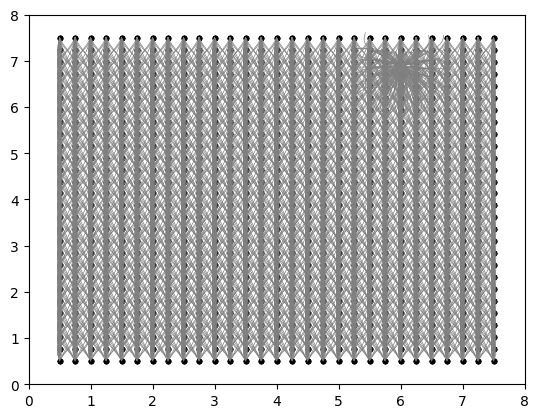

In [3]:
sp.plot_reachable('F')

In [4]:
reachable = pickle.load(open('planning/pre_compute/reachable_1.5_7_2K_ramp_unfiltered.pkl', 'rb'))
Pset = pickle.load(open('planning/pre_compute/Pset_1.5_7_2K_ramp_unfiltered.pkl', 'rb'))
close_up = np.where(np.array(Pset)[:,1] < 1)[0]

new_Pset = []

for idx in close_up:
    node = Pset[idx]
    new_Pset.append([node[0], node[1], node[2], 0.5])
    node_slow2 = [node[0], node[1], node[2], 1]

array([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,  100,
        101,  102,  103,  104,  105,  106,  107,  108,  109,  200,  201,
        202,  203,  204,  205,  206,  207,  208,  209,  300,  301,  302,
        303,  304,  305,  306,  307,  308,  309,  400,  401,  402,  403,
        404,  405,  406,  407,  408,  409,  500,  501,  502,  503,  504,
        505,  506,  507,  508,  509,  600,  601,  602,  603,  604,  605,
        606,  607,  608,  609,  700,  701,  702,  703,  704,  705,  706,
        707,  708,  709,  800,  801,  802,  803,  804,  805,  806,  807,
        808,  809,  900,  901,  902,  903,  904,  905,  906,  907,  908,
        909, 1000, 1001, 1002, 1003, 1004, 1005, 1006, 1007, 1008, 1009,
       1100, 1101, 1102, 1103, 1104, 1105, 1106, 1107, 1108, 1109, 1200,
       1201, 1202, 1203, 1204, 1205, 1206, 1207, 1208, 1209, 1300, 1301,
       1302, 1303, 1304, 1305, 1306, 1307, 1308, 1309, 1400, 1401, 1402,
       1403, 1404, 1405, 1406, 1407, 1408, 1409, 15

In [9]:
len(Pset)

2001

In [5]:
np.linspace(0,1.5,num=2)

array([0. , 1.5])

Sample planning

In [5]:
boxes = np.array([[[1,4],[3.5,6]],
                  [[2,3],[2.5,3.5]],
                  [[5.3,2.5],[6,3]]])
state = np.array([init_state])
res = sp.plan(state, boxes)
# res[0] = idx of nodes in the path
# res[1] = [x_trajectory]
# res[2] = [u_trajectory]

Plotting

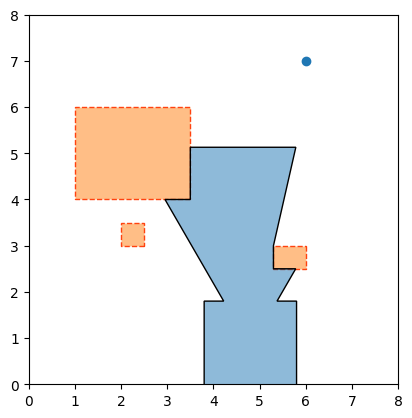

In [7]:
sp.show(res[0])